# 02 — Data Cleaning & EDA
## Dataset: IEEE-CIS Fraud Detection

**Mục tiêu**:
- Load & join `train_transaction` + `train_identity`
- Data Cleaning (missing rất nhiều)
- EDA tập trung vào target, amount, thời gian, device/identity
- Đánh giá khả năng dùng cho Graph (device/IP sharing)

**Files kỳ vọng**:
```
train_transaction.csv
train_identity.csv
```
(Có thể có test_transaction / test_identity nhưng Phase 1 chỉ cần train)

## 0. Setup & Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import missingno as msno
except ImportError:
    msno = None
    print("missingno chưa cài → pip install missingno")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries loaded.")

Libraries loaded.


In [3]:
# ====== CẤU HÌNH ĐƯỜNG DẪN ======
DATA_DIR = Path("../data/raw/ieee_cis")       
PROCESSED_DIR = Path("../data/processed/ieee_cis_processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR exists:", DATA_DIR.exists())
if DATA_DIR.exists():
    for f in sorted(DATA_DIR.glob("*.csv")):
        print(f"  - {f.name} ({f.stat().st_size / 1e6:.1f} MB)")

DATA_DIR exists: True
  - test_identity.csv (25.8 MB)
  - test_transaction.csv (613.2 MB)
  - train_identity.csv (26.5 MB)
  - train_transaction.csv (683.4 MB)


## 1. Load dữ liệu

In [4]:
def load_csv(name: str, **kwargs) -> pd.DataFrame:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy: {path}")
    df = pd.read_csv(path, **kwargs)
    print(f"Loaded {name:30s} → {df.shape[0]:>10,} rows × {df.shape[1]} cols")
    return df

# Load 2 bảng chính
trans = load_csv("train_transaction.csv")
ident = load_csv("train_identity.csv")

Loaded train_transaction.csv          →    590,540 rows × 394 cols
Loaded train_identity.csv             →    144,233 rows × 41 cols


In [4]:
print("=== train_transaction ===")
display(trans.head())
print("\nColumns (first 40):", trans.columns[:40].tolist())
print("... total", len(trans.columns), "columns")

print("\n=== train_identity ===")
display(ident.head())
print("\nColumns:", ident.columns.tolist())

=== train_transaction ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.500,W,13926,NaN,150.000,discover,142.000,credit,315.000,87.000,19.000,NaN,NaN,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,2.000,0.000,1.000,1.000,14.000,NaN,13.000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,117.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,117.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.000,W,2755,404.000,150.000,mastercard,102.000,credit,325.000,87.000,NaN,NaN,gmail.com,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.000,W,4663,490.000,150.000,visa,166.000,debit,330.000,87.000,287.000,NaN,outlook.com,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.000,W,18132,567.000,150.000,mastercard,117.000,debit,476.000,87.000,NaN,NaN,yahoo.com,NaN,2.000,5.000,0.000,0.000,0.000,4.000,0.000,0.000,1.000,0.000,1.000,0.000,25.000,1.000,112.000,112.000,0.000,94.000,0.000,NaN,NaN,NaN,NaN,...,0.000,0.000,0.000,0.000,0.000,1.000,50.000,1758.000,925.000,0.000,354.000,0.000,135.000,0.000,0.000,0.000,50.000,1404.000,790.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.000,H,4497,514.000,150.000,mastercard,102.000,credit,420.000,87.000,NaN,NaN,gmail.com,NaN,1.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,0.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000



Columns (first 40): ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9']
... total 394 columns

=== train_identity ===


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.000,70787.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000,NotFound,NaN,-480.000,New,NotFound,166.000,NaN,542.000,144.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.000,98945.000,NaN,NaN,0.000,-5.000,NaN,NaN,NaN,NaN,100.000,NotFound,49.000,-300.000,New,NotFound,166.000,NaN,621.000,500.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.000,191631.000,0.000,0.000,0.000,0.000,NaN,NaN,0.000,0.000,100.000,NotFound,52.000,NaN,Found,Found,121.000,NaN,410.000,142.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.000,221832.000,NaN,NaN,0.000,-6.000,NaN,NaN,NaN,NaN,100.000,NotFound,52.000,NaN,New,NotFound,225.000,NaN,176.000,507.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.000,7460.000,0.000,0.000,1.000,0.000,NaN,NaN,0.000,0.000,100.000,NotFound,NaN,-300.000,Found,Found,166.000,15.000,529.000,575.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.000,1280x800,match_status:2,T,F,T,T,desktop,MacOS



Columns: ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


## 2. Join 2 bảng

In [5]:
# Kiểm tra key
print("TransactionID unique in trans :", trans["TransactionID"].is_unique)
print("TransactionID unique in ident :", ident["TransactionID"].is_unique)
print("Overlap TransactionID        :", len(set(trans["TransactionID"]) & set(ident["TransactionID"])))

# Left join (giữ tất cả giao dịch)
df = trans.merge(ident, on="TransactionID", how="left")
print(f"\nSau join: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Tỷ lệ có identity info: {df['id_01'].notna().mean()*100:.1f}%")

TransactionID unique in trans : True
TransactionID unique in ident : True
Overlap TransactionID        : 144233

Sau join: 590,540 rows × 434 columns
Tỷ lệ có identity info: 24.4%


## 3. Data Cleaning

### 3.1 Missing values (IEEE-CIS missing rất nhiều)

In [6]:
def missing_report(df: pd.DataFrame, top_n: int = 30):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({"missing": miss, "pct": miss_pct})
    report = report[report["missing"] > 0].sort_values("pct", ascending=False)
    print(f"Số cột có missing: {len(report)} / {df.shape[1]}")
    display(report.head(top_n))
    return report

miss_report = missing_report(df, top_n=40)

Số cột có missing: 414 / 434


,missing,pct
id_24,585793,99.200
id_07,585385,99.130
id_25,585408,99.130
id_08,585385,99.130
id_26,585377,99.130
id_21,585381,99.130
id_23,585371,99.120
id_22,585371,99.120
id_27,585371,99.120
dist2,552913,93.630


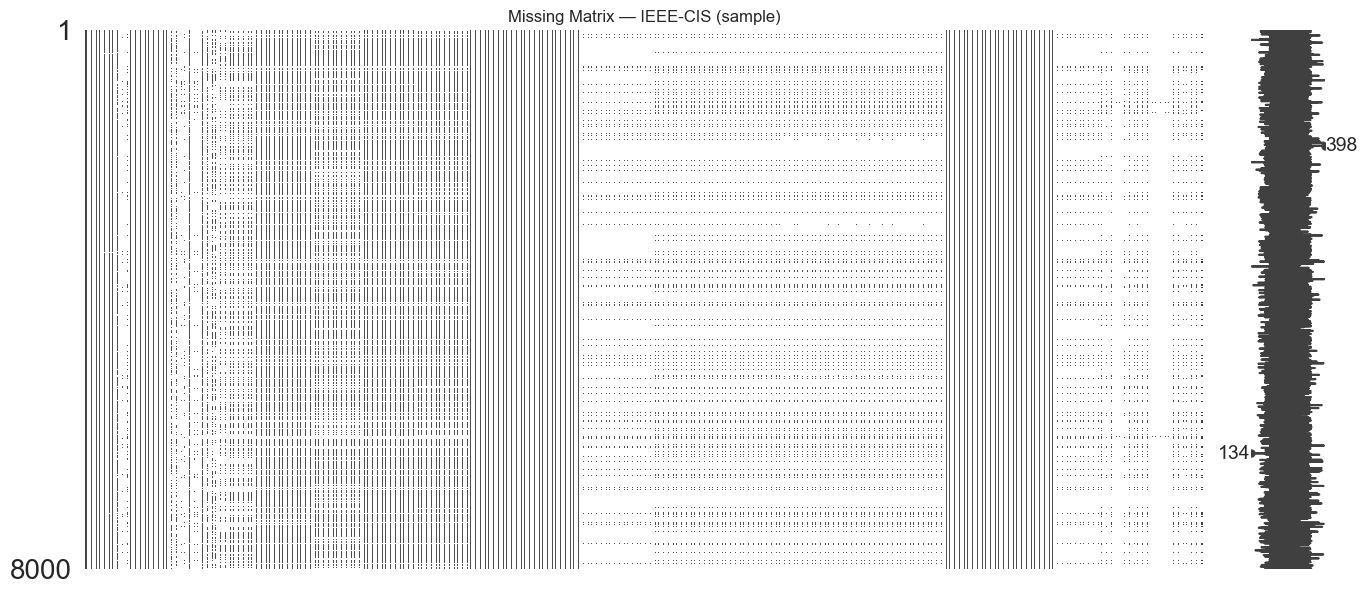

In [8]:
# Visualize missing (sample để nhanh)
if msno is not None:
    sample = df.sample(min(8000, len(df)), random_state=42)
    msno.matrix(sample, figsize=(16, 7))
    plt.title("Missing Matrix — IEEE-CIS (sample)")
    plt.show()

In [9]:
# Quyết định drop cột missing quá cao
HIGH_MISS_THRESHOLD = 90   # % 
high_miss_cols = miss_report[miss_report["pct"] > HIGH_MISS_THRESHOLD].index.tolist()
print(f"Số cột missing > {HIGH_MISS_THRESHOLD}%: {len(high_miss_cols)}")
print(high_miss_cols[:20], "...")

# Giữ lại một số cột identity quan trọng dù missing cao (DeviceType, DeviceInfo, id_*)
keep_despite_missing = [c for c in high_miss_cols if c.startswith("id_") or c in ["DeviceType", "DeviceInfo"]]
drop_cols = [c for c in high_miss_cols if c not in keep_despite_missing]

print(f"\nSẽ drop {len(drop_cols)} cột")
print(f"Giữ lại dù missing cao: {keep_despite_missing}")

Số cột missing > 90%: 12
['id_24', 'id_07', 'id_25', 'id_08', 'id_26', 'id_21', 'id_23', 'id_22', 'id_27', 'dist2', 'D7', 'id_18'] ...

Sẽ drop 2 cột
Giữ lại dù missing cao: ['id_24', 'id_07', 'id_25', 'id_08', 'id_26', 'id_21', 'id_23', 'id_22', 'id_27', 'id_18']


In [ ]:
# Thực hiện drop (có thể comment nếu muốn giữ tất cả)
# df = df.drop(columns=drop_cols)
# print("Shape sau drop:", df.shape)

### 3.2 Duplicates

In [10]:
print("Duplicate rows          :", df.duplicated().sum())
print("Duplicate TransactionID :", df["TransactionID"].duplicated().sum())

Duplicate rows          : 0
Duplicate TransactionID : 0


### 3.3 Kiểu dữ liệu & chuyển đổi

In [19]:
# Target
df["isFraud"] = df["isFraud"].astype("int8")

# TransactionDT là số giây từ một mốc thời gian → giữ nguyên hoặc tạo ngày giả
# (không convert sang datetime thật vì không biết mốc)
print("TransactionDT range:", df["TransactionDT"].min(), "→", df["TransactionDT"].max())

# Các cột categorical phổ biến
cat_cols = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
    "DeviceType", "DeviceInfo",
    "id_12", "id_15", "id_16", "id_23", "id_27", "id_28", "id_29", "id_30",
    "id_31", "id_33", "id_34", "id_35", "id_36", "id_37", "id_38"
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# card1, card2, addr1... thường để category hoặc giữ số
for col in ["card1", "card2", "card3", "card5", "addr1", "addr2"]:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("\nDtypes sau convert (sample):")
print(df.dtypes.value_counts())

TransactionDT range: 86400 → 15811131

Dtypes sau convert (sample):
float64     394
category     12
category      4
int64         3
int8          1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


### 3.4 Kiểm tra logic & giá trị bất thường

### 3.5 Lưu bản clean (tùy chọn)

In [22]:
def safe_to_parquet(df: pd.DataFrame, path: Path):
    df_save = df.copy()
    for col in df_save.select_dtypes(include=["category"]).columns:
        df_save[col] = df_save[col].astype("string")
    for col in df_save.select_dtypes(include=["Int32", "Int64"]).columns:
        df_save[col] = df_save[col].astype("float64")
    df_save.to_parquet(path, index=False, engine="pyarrow")
    print(f"Saved: {path} ({path.stat().st_size/1e6:.1f} MB)")

# Uncomment khi đã hài lòng
safe_to_parquet(df, PROCESSED_DIR / "ieee_cis_train_clean.parquet")

Saved: ..\data\processed\ieee_cis_processed\ieee_cis_train_clean.parquet (84.8 MB)


## 4. Exploratory Data Analysis

### 4.1 Target Distribution

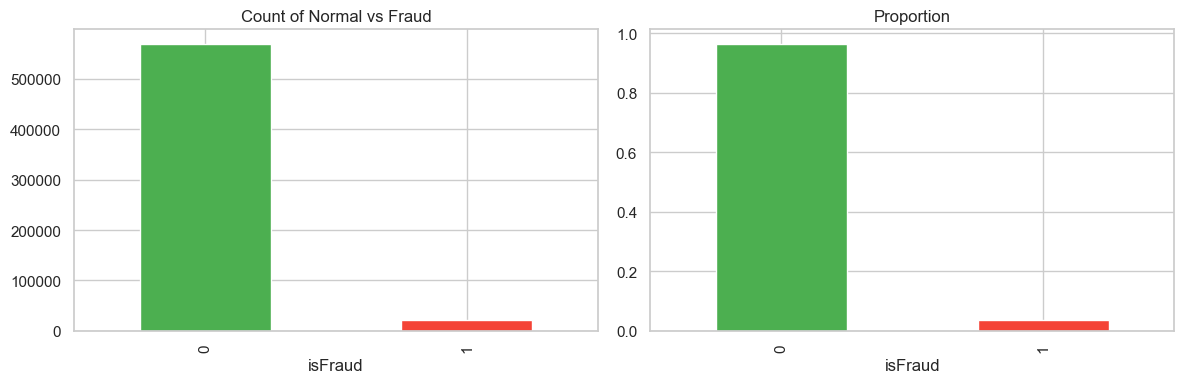

Fraud rate: 3.499%


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["isFraud"].value_counts().plot(kind="bar", ax=ax[0], color=["#4caf50", "#f44336"])
ax[0].set_title("Count of Normal vs Fraud")

df["isFraud"].value_counts(normalize=True).plot(kind="bar", ax=ax[1], color=["#4caf50", "#f44336"])
ax[1].set_title("Proportion")
plt.tight_layout()
plt.show()

print(f"Fraud rate: {df['isFraud'].mean()*100:.3f}%")

### 4.2 TransactionAmt

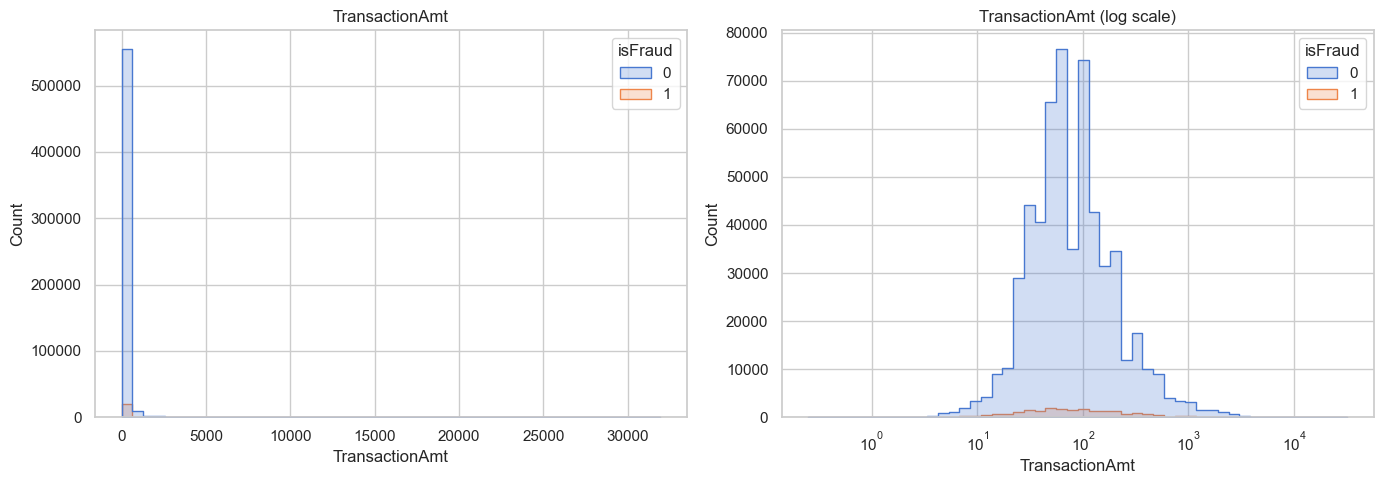

             count    mean     std   min    25%    50%     75%       max
isFraud                                                                 
0       569877.000 134.512 239.395 0.251 43.970 68.500 120.000 31937.391
1        20663.000 149.245 232.212 0.292 35.044 75.000 161.000  5191.000


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="TransactionAmt", hue="isFraud", bins=50, ax=axes[0], element="step")
axes[0].set_title("TransactionAmt")

sns.histplot(data=df[df["TransactionAmt"] > 0], x="TransactionAmt", hue="isFraud",
             bins=50, log_scale=True, ax=axes[1], element="step")
axes[1].set_title("TransactionAmt (log scale)")

plt.tight_layout()
plt.show()

print(df.groupby("isFraud")["TransactionAmt"].describe())

### 4.3 Thời gian (TransactionDT)

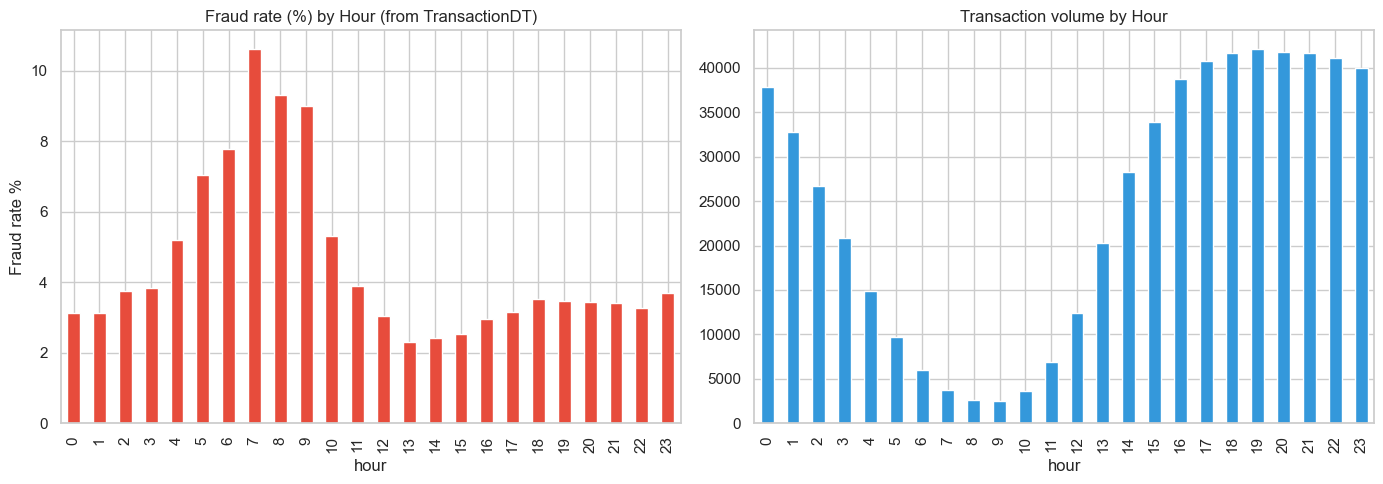

In [13]:
# TransactionDT là giây từ mốc → tạo hour-of-day giả định
df["hour"] = ((df["TransactionDT"] // 3600) % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_fraud = df.groupby("hour")["isFraud"].mean() * 100
hourly_fraud.plot(kind="bar", ax=axes[0], color="#e74c3c")
axes[0].set_title("Fraud rate (%) by Hour (from TransactionDT)")
axes[0].set_ylabel("Fraud rate %")

df.groupby("hour").size().plot(kind="bar", ax=axes[1], color="#3498db")
axes[1].set_title("Transaction volume by Hour")

plt.tight_layout()
plt.show()

### 4.4 Các cột categorical quan trọng


=== ProductCD ===
isFraud        0      1
ProductCD              
C         88.313 11.687
H         95.234  4.766
R         96.217  3.783
S         94.100  5.900
W         97.960  2.040


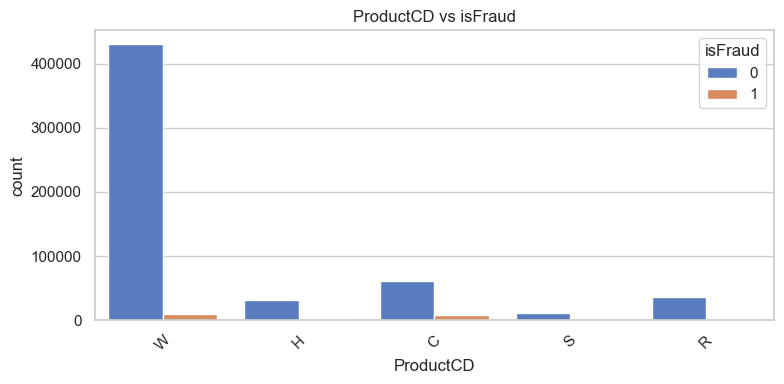


=== card4 ===
isFraud               0     1
card4                        
american express 97.130 2.870
discover         92.272 7.728
mastercard       96.567 3.433
visa             96.524 3.476


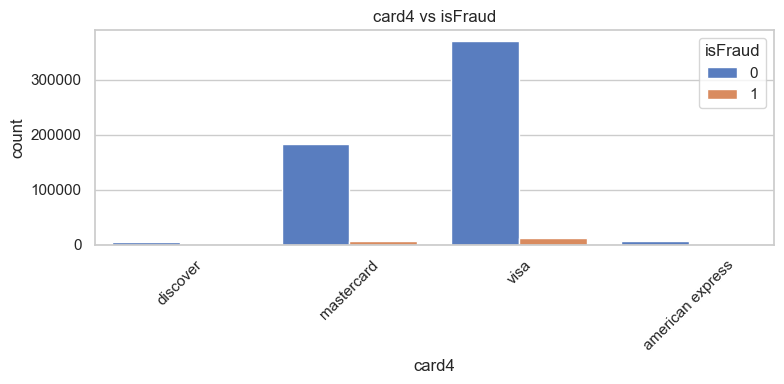


=== card6 ===
isFraud               0     1
card6                        
charge card     100.000 0.000
credit           93.322 6.678
debit            97.574 2.426
debit or credit 100.000 0.000


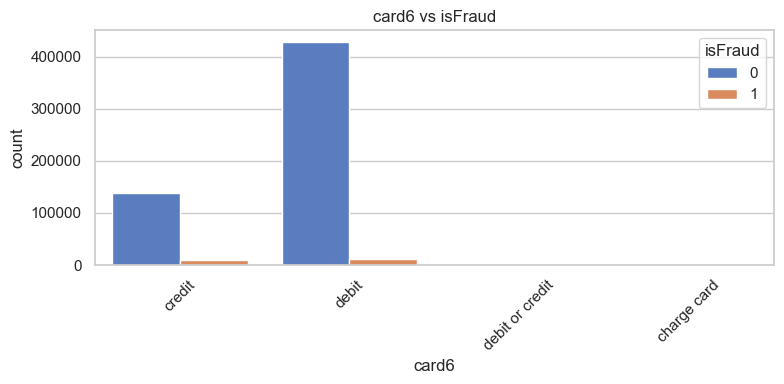


=== DeviceType ===
isFraud         0      1
DeviceType              
desktop    93.479  6.521
mobile     89.834 10.166


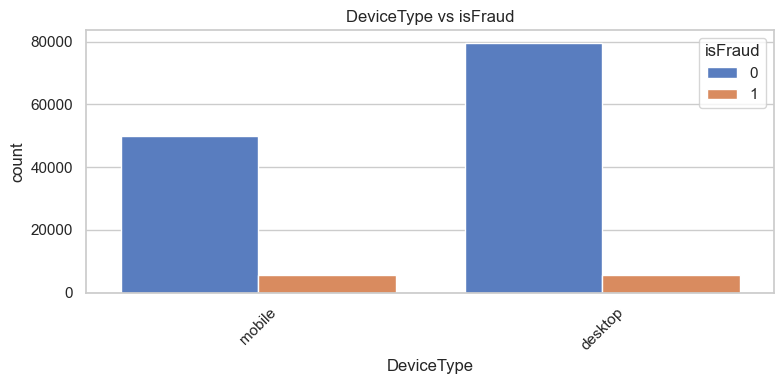

In [14]:
cat_check = ["ProductCD", "card4", "card6", "DeviceType"]

for col in cat_check:
    if col not in df.columns:
        continue
    print(f"\n=== {col} ===")
    ct = pd.crosstab(df[col], df["isFraud"], normalize="index") * 100
    print(ct)
    
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="isFraud")
    plt.title(f"{col} vs isFraud")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 4.5 Device / Identity (quan trọng cho Graph sau này)

In [15]:
print("DeviceType value counts:")
print(df["DeviceType"].value_counts(dropna=False).head(10))

print("\nDeviceInfo top 15:")
print(df["DeviceInfo"].value_counts(dropna=False).head(15))

print("\nid_30 (OS) top 10:")
if "id_30" in df.columns:
    print(df["id_30"].value_counts(dropna=False).head(10))

print("\nid_31 (Browser) top 10:")
if "id_31" in df.columns:
    print(df["id_31"].value_counts(dropna=False).head(10))

DeviceType value counts:
DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

DeviceInfo top 15:
DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
Name: count, dtype: int64

id_30 (OS) top 10:
id_30
NaN                 512975
Windows 10           21155
Windows 7            13110
iOS 11.2.1            3722
iOS 11.1.2            3699
Android 7.0           2871
Mac OS X 10_12_6      2559
Mac OS X 10_11_6      2348
iOS 11.3.0     

In [16]:
# Kiểm tra khả năng chia sẻ device (rất quan trọng cho Graph)
# DeviceInfo hoặc id_31 có được nhiều TransactionID / card khác nhau dùng không?

if "DeviceInfo" in df.columns:
    device_share = df.groupby("DeviceInfo")["TransactionID"].nunique().sort_values(ascending=False)
    print("Top DeviceInfo by number of transactions:")
    print(device_share.head(15))
    print(f"\nDeviceInfo xuất hiện > 50 lần: {(device_share > 50).sum()}")

Top DeviceInfo by number of transactions:
DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
Name: TransactionID, dtype: int64

DeviceInfo xuất hiện > 50 lần: 141


### 4.6 Correlation với target (các cột số)

In [17]:
# Lấy một số cột số phổ biến
num_cols = ["TransactionAmt", "card1", "card2", "card3", "card5", "addr1", "addr2",
            "C1", "C2", "C11", "C13", "D1", "D2", "D15"]
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols + ["isFraud"]].corr()["isFraud"].sort_values(ascending=False)
print(corr)

isFraud           1.000
card3             0.154
C2                0.037
C1                0.031
C11               0.027
TransactionAmt    0.011
addr1             0.006
card2             0.003
C13              -0.011
card1            -0.014
addr2            -0.030
card5            -0.034
D1               -0.067
D15              -0.078
D2               -0.084
Name: isFraud, dtype: float64


## 5. Tổng hợp Insight

In [18]:
summary = {
    "total_transactions": len(df),
    "fraud_rate_pct": round(df["isFraud"].mean() * 100, 3),
    "n_columns_after_join": df.shape[1],
    "pct_has_identity": round(df["id_01"].notna().mean() * 100, 1) if "id_01" in df.columns else None,
    "n_unique_card1": df["card1"].nunique() if "card1" in df.columns else None,
    "n_unique_DeviceInfo": df["DeviceInfo"].nunique() if "DeviceInfo" in df.columns else None,
    "has_TransactionDT": "TransactionDT" in df.columns,
}

print("=== SUMMARY IEEE-CIS ===")
for k, v in summary.items():
    print(f"{k:25s}: {v}")

=== SUMMARY IEEE-CIS ===
total_transactions       : 590540
fraud_rate_pct           : 3.499
n_columns_after_join     : 435
pct_has_identity         : 24.4
n_unique_card1           : 13553
n_unique_DeviceInfo      : 1786
has_TransactionDT        : True


## 6. Kết luận & So sánh với bộ 1M

Sau khi chạy xong, hãy trả lời:

1. Fraud rate IEEE-CIS là bao nhiêu? (thường ~3.5%)
2. Tỷ lệ giao dịch có identity info?
3. DeviceInfo / id_31 có đủ cardinality để làm graph không?
4. Missing có quá nặng không? Cần drop bao nhiêu cột?
5. So với bộ 1M: bộ nào sạch và sẵn sàng hơn cho baseline + graph?

**Next steps**:
- Nếu IEEE-CIS đủ tốt → Feature Engineering + Baseline trên IEEE-CIS
- Nếu thiếu tín hiệu graph → dùng bộ 1M làm chính, IEEE-CIS chỉ để benchmark